In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\DELL\Documents\Churn-Project\Customer-Churn.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
df.shape

(7043, 31)

In [3]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [4]:
df = pd.read_csv(r"C:\Users\DELL\Documents\Churn-Project\Customer-Churn.csv")

In [5]:
df['Churn'].unique()
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

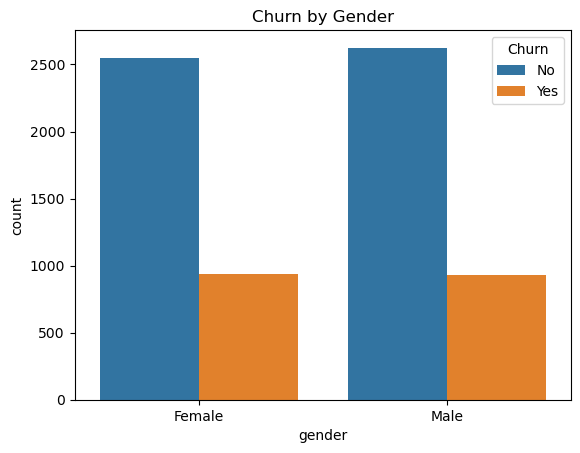

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Churn by Gender")
plt.show()

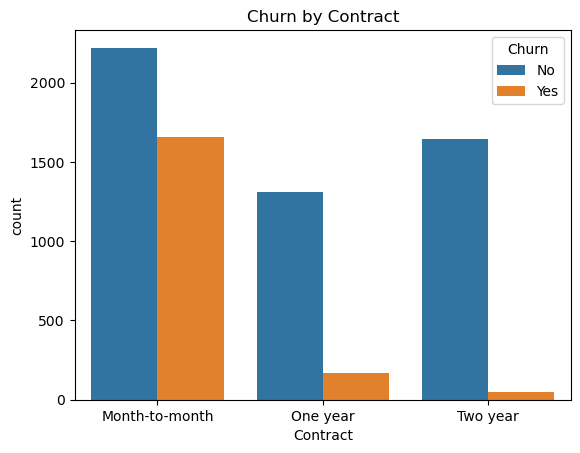

In [7]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract")
plt.show()

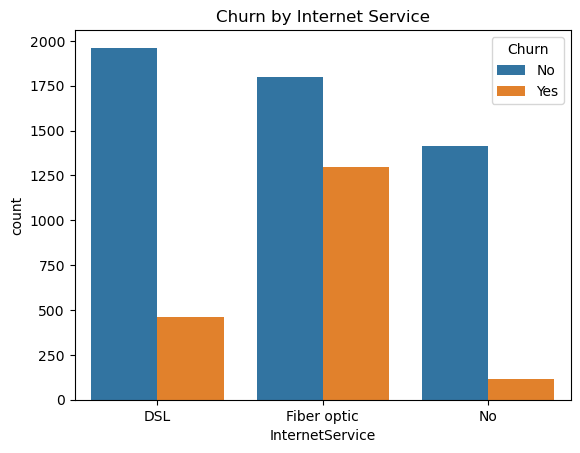

In [8]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Churn by Internet Service")
plt.show()

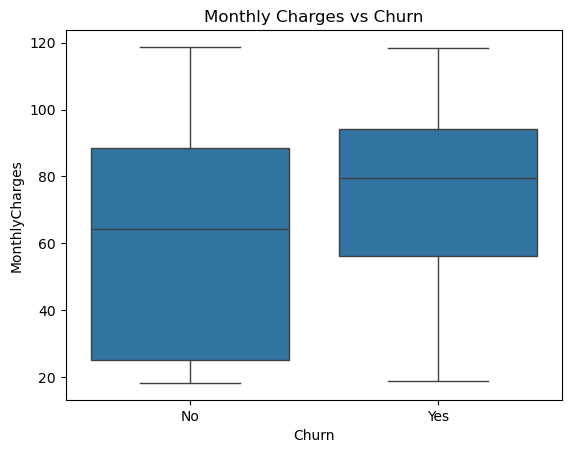

In [9]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

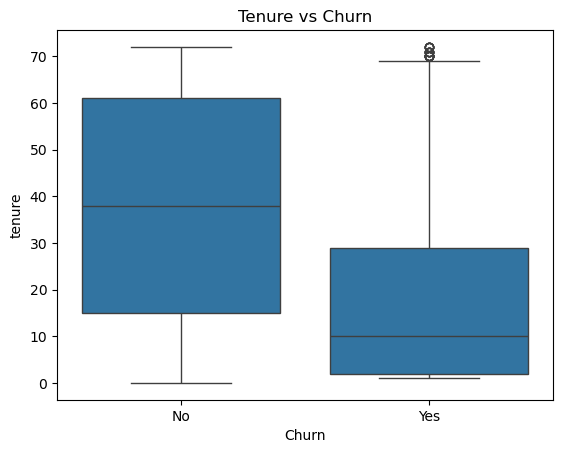

In [10]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")
plt.show()

In [11]:
df.drop('customerID', axis=1, inplace=True)

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic',
       ...
       'TotalCharges_996.45', 'TotalCharges_996.85', 'TotalCharges_996.95',
       'TotalCharges_997.65', 'TotalCharges_997.75', 'TotalCharges_998.1',
       'TotalCharges_999.45', 'TotalCharges_999.8', 'TotalCharges_999.9',
       'Churn_Yes'],
      dtype='object', length=6560)

In [15]:
y = df['Churn_Yes'] 

In [16]:
X = df.drop('Churn_Yes', axis=1)

In [18]:
# Separate features and target
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [19]:
df = pd.read_csv(r"C:\Users\DELL\Documents\Churn-Project\Customer-Churn.csv")

In [21]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [22]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [23]:
df.drop('customerID', axis=1, inplace=True)
df = pd.get_dummies(df, drop_first=True)

In [24]:
df.shape

(7043, 31)

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8204400283889283


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[934 102]
 [151 222]]


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [35]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7083037615330021


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [38]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7920511000709723


In [39]:
print("Logistic Regression:", accuracy)
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.8204400283889283
Decision Tree: 0.7083037615330021
Random Forest: 0.7920511000709723


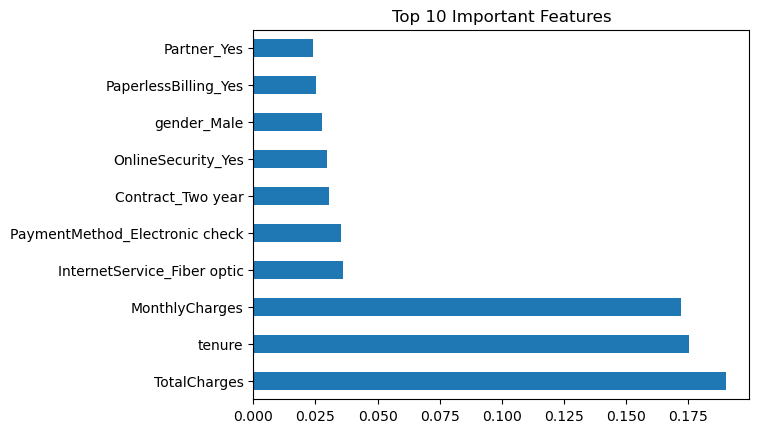

In [40]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [44]:
df_viz = pd.read_csv(r"C:\Users\DELL\Documents\Churn-Project\Customer-Churn.csv")

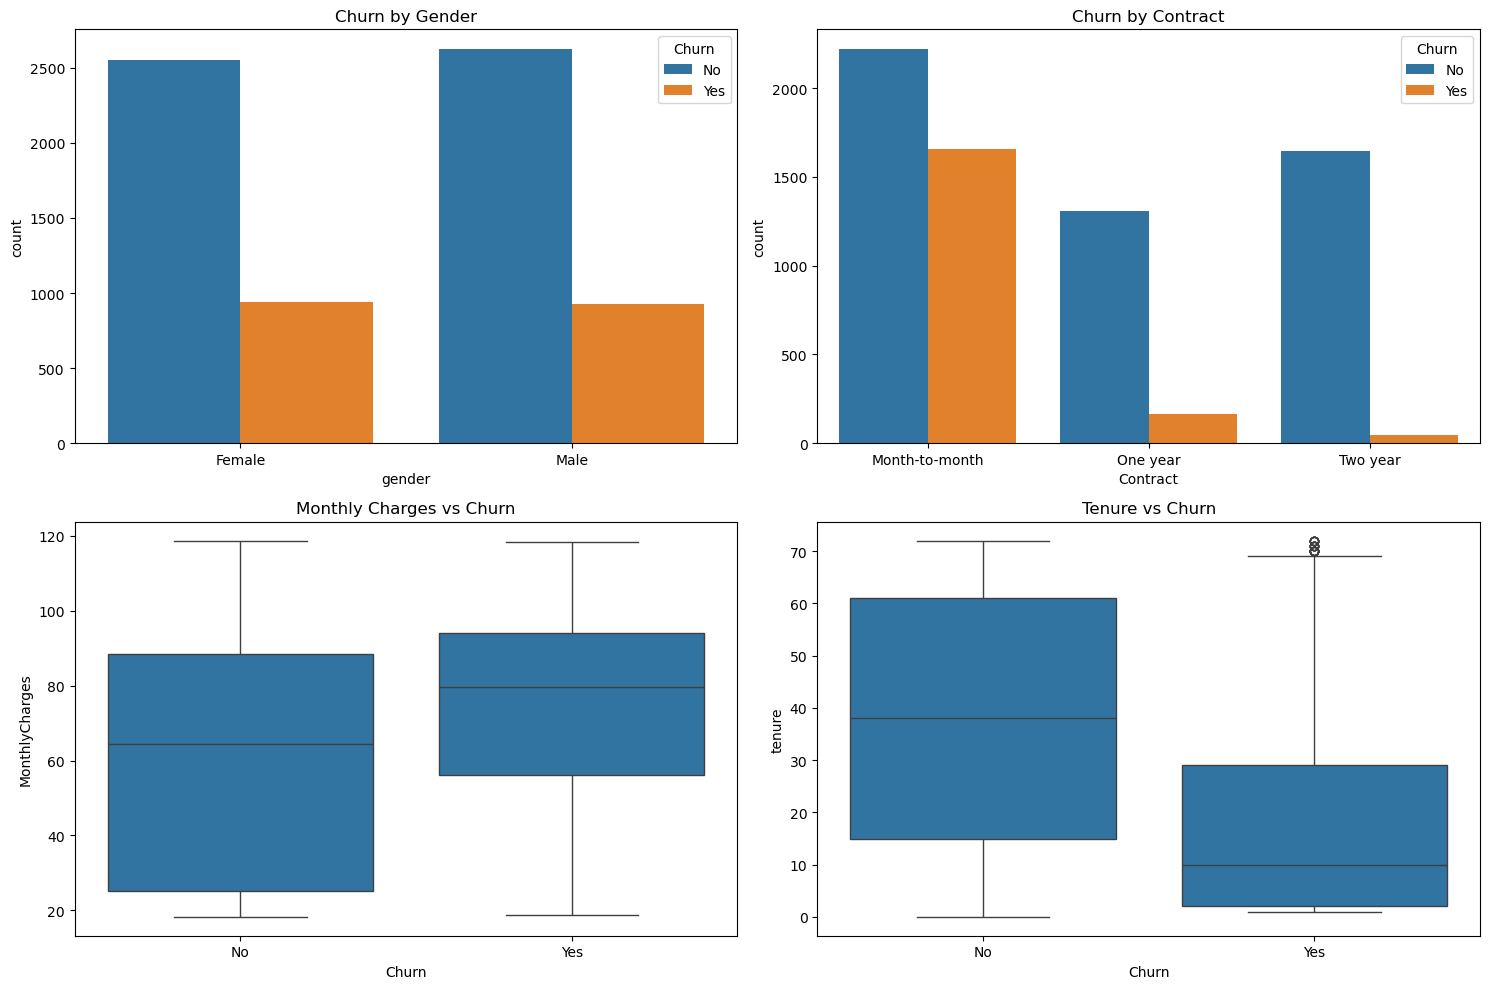

In [46]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(x='gender', hue='Churn', data=df_viz)
plt.title("Churn by Gender")

plt.subplot(2,2,2)
sns.countplot(x='Contract', hue='Churn', data=df_viz)
plt.title("Churn by Contract")

plt.subplot(2,2,3)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_viz)
plt.title("Monthly Charges vs Churn")

plt.subplot(2,2,4)
sns.boxplot(x='Churn', y='tenure', data=df_viz)
plt.title("Tenure vs Churn")

plt.tight_layout()
plt.show()

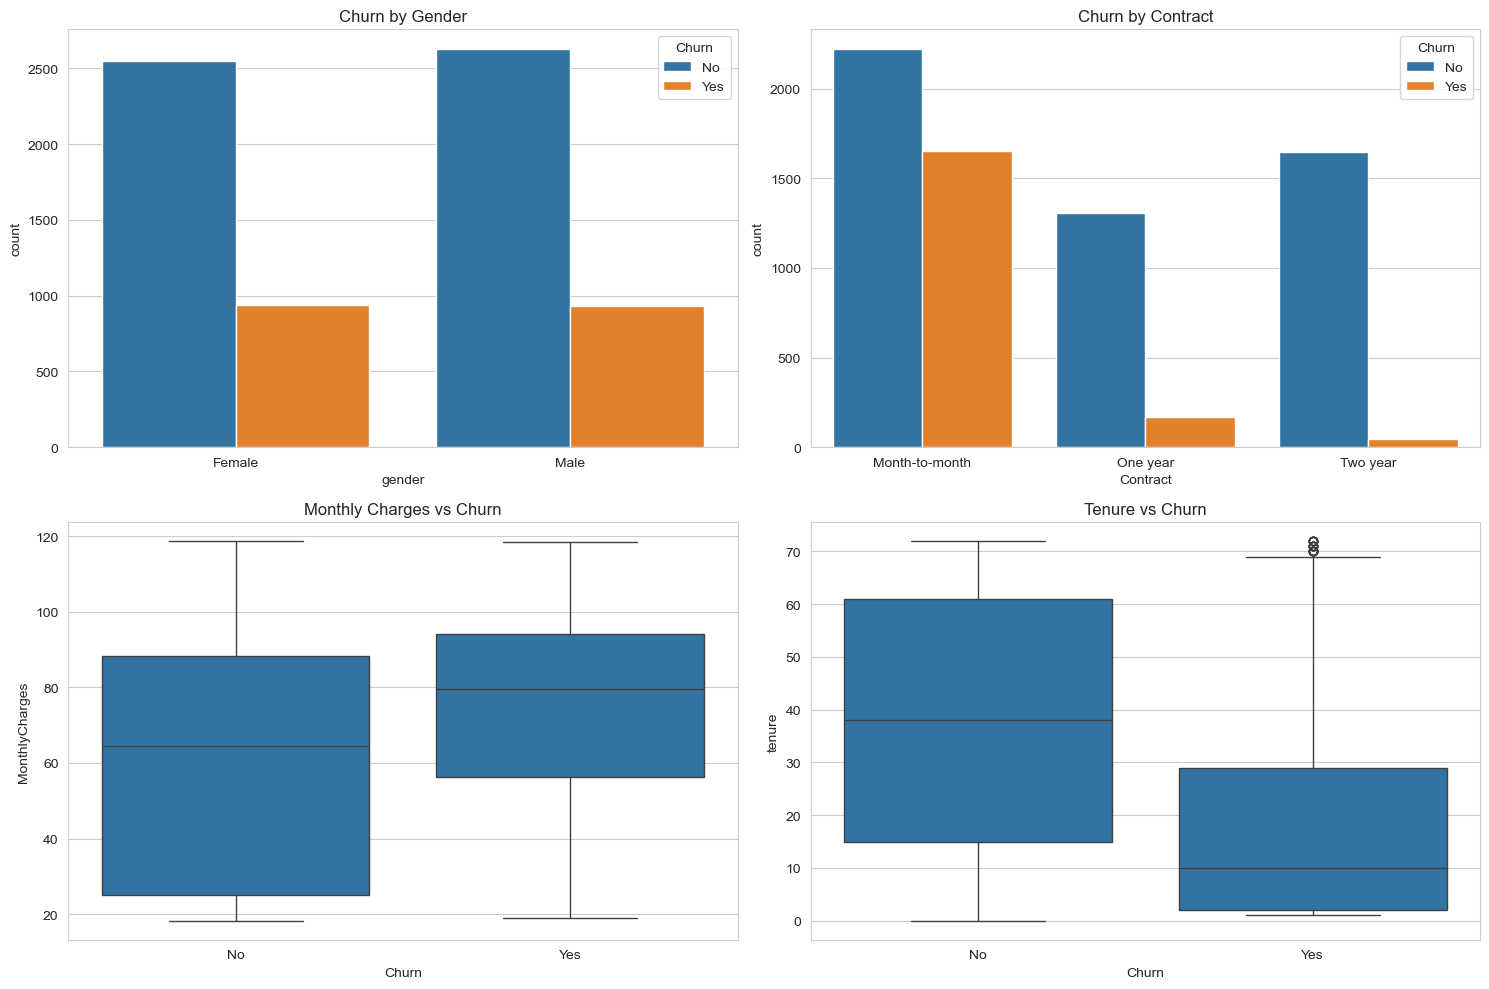

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load original dataset for visualization
df_viz = pd.read_csv(r"C:\Users\DELL\Documents\Churn-Project\Customer-Churn.csv")

# Apply style
sns.set_style("whitegrid")

# Create dashboard
plt.figure(figsize=(15,10))

# Chart 1
plt.subplot(2,2,1)
sns.countplot(x='gender', hue='Churn', data=df_viz)
plt.title("Churn by Gender")

# Chart 2
plt.subplot(2,2,2)
sns.countplot(x='Contract', hue='Churn', data=df_viz)
plt.title("Churn by Contract")

# Chart 3
plt.subplot(2,2,3)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_viz)
plt.title("Monthly Charges vs Churn")

# Chart 4
plt.subplot(2,2,4)
sns.boxplot(x='Churn', y='tenure', data=df_viz)
plt.title("Tenure vs Churn")

plt.tight_layout()
plt.show()